# IMPORTS

In [16]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from io import BytesIO
from PIL import Image
from pydub import AudioSegment
from pydub.utils import which
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import cv2
from sklearn.model_selection import GroupShuffleSplit
import warnings

# DATASET

## CREMA-D

### Load CREMA-D

In [2]:
dataset_folder = "dataset\\CREMA-D\\AudioWAV\\"

data = []

emotion_map = {
    "ANG": "Anger",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad",
}


for file in os.listdir(dataset_folder):
    filename, _ = os.path.splitext(file)

    parts = filename.split("_")

    # Speaker
    speaker = parts[0]

    # Path
    path = os.path.join(dataset_folder, file)

    # Emotion
    emotion_code = parts[2]
    emotion = emotion_map.get(emotion_code, "Unknown")

    data.append([speaker, path, emotion])

dataset = pd.DataFrame(data, columns=["speaker", "path", "emotion"])
print(dataset.count())

speaker    7442
path       7442
emotion    7442
dtype: int64


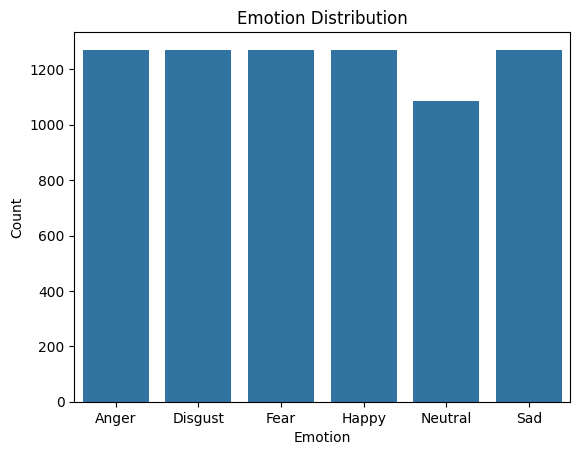

In [3]:
sns.countplot(x="emotion", data=dataset)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [4]:
def create_csv(df: pd.DataFrame, output_csv: str):
    df.to_csv(output_csv, index=False)

os.makedirs("CSVs", exist_ok=True)
    
create_csv(dataset, "CSVs\\dataset.csv")

### Remove silence

In [ ]:
AudioSegment.converter = which("ffmpeg")

location = "dataset_silenced\\"
os.makedirs(location, exist_ok=True)


def detect_leading_silence(dls_audio):
    dls_chunk_size = 10
    dls_silence_threshold = -50.0

    trim_ms = 0
    dls_audio_length = len(dls_audio)

    while trim_ms < dls_audio_length:
        chunk_dBFS = dls_audio[trim_ms : trim_ms + dls_chunk_size].dBFS
        if chunk_dBFS > dls_silence_threshold:
            break
        trim_ms += dls_chunk_size

    return trim_ms


name = 0
errors = 0
file_data = []

# Process each audio file, remove leading and trailing silence, and save the new audio files
for _, row in dataset.iterrows():
    file_name = f"{location}{name}.wav"

    try:
        audio = AudioSegment.from_file(row["path"], format="wav")
    except:  # noqa: E722
        audio = AudioSegment.from_file(row["path"])

    start_trim = detect_leading_silence(audio)
    end_trim = detect_leading_silence(audio.reverse())

    duration = len(audio)
    new_audio = audio[start_trim : duration - end_trim]

    if len(new_audio) > 0:
        os.makedirs(os.path.dirname(file_name), exist_ok=True)
        new_audio.export(file_name, format="wav")
    else:
        audio.export(file_name, format="wav")
        errors += 1
        print(f"Audio too short: {row['path']}, saved original audio.")

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

dataset_silenced = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(dataset_silenced, "CSVs\\dataset_silenced.csv")

Error processing dataset\CREMA-D\AudioWAV\1076_MTI_SAD_XX.wav, saved original audio.


### Split dataset

In [6]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, temp_idx = next(gss.split(dataset_silenced, groups=dataset_silenced["speaker"]))

gss = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=42)
val_idx, test_idx = next(
    gss.split(
        dataset_silenced.loc[temp_idx], groups=dataset_silenced.loc[temp_idx]["speaker"]
    )
)

train_df = dataset_silenced.iloc[train_idx].reset_index(drop=True)
val_df = dataset_silenced.iloc[temp_idx].iloc[val_idx].reset_index(drop=True)
test_df = dataset_silenced.iloc[temp_idx].iloc[test_idx].reset_index(drop=True)

print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

create_csv(train_df, "CSVs\\train.csv")
create_csv(val_df, "CSVs\\val.csv")
create_csv(test_df, "CSVs\\test.csv")

Train set: 5890 samples
Validation set: 732 samples
Test set: 820 samples


### Data augmentation

In [7]:
import random

location = "dataset_augmented\\"
os.makedirs(location, exist_ok=True)


def noise(n_data):
    noise_amp = 0.005 * np.random.uniform() * np.max(np.abs(n_data))
    return n_data + noise_amp * np.random.normal(size=n_data.shape[0])


def stretch(s_data):
    s_rate = np.random.uniform(0.95, 1.05)
    return librosa.effects.time_stretch(s_data, rate=s_rate)


def pitch(p_data, p_sampling_rate):
    p_pitch_factor = np.random.uniform(-1, 1)
    return librosa.effects.pitch_shift(
        p_data, sr=p_sampling_rate, n_steps=p_pitch_factor
    )


name = 0
file_data = []

# Process each audio file, apply random augmentation, and save the new audio files
for _, row in train_df.iterrows():
    data, sampling_rate = librosa.load(row["path"], sr=None)

    # Original audio
    file_name = f"{location}{name}.wav"
    sf.write(file_name, data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

    # Randomly select an augmentation type
    aug_type = random.choices(
        ["noise", "stretch", "pitch"], weights=[0.4, 0.3, 0.3], k=1
    )[0]

    augment_map = {
        "noise": lambda: noise(data),
        "stretch": lambda: stretch(data),
        "pitch": lambda: pitch(data, sampling_rate),
    }

    aug_data = augment_map[aug_type]()

    file_name = f"{location}{name}.wav"
    sf.write(file_name, aug_data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

    print(f"Processed {name} files", end="\r", flush=True)


train_df_augmented = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(train_df_augmented, "CSVs\\dataset_augmented.csv")

# CONVERT TO MEL SPECTROGRAM

## Config

In [ ]:
location = "features\\"
csv_dir = "CSVs\\"
train_df_augmented = pd.read_csv(os.path.join(csv_dir, "dataset_augmented.csv"))
val_df = pd.read_csv(os.path.join(csv_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(csv_dir, "test.csv"))

MIN_SAMPLES = 2048
TARGET_DURATION = 3.0  # seconds
IMG_SIZE = 224

# Mel params 
# Đây là số lượng dải Mel sẽ được sử dụng để tạo ra spectrogram. 
# Số lượng này ảnh hưởng đến độ phân giải của spectrogram và 
# khả năng mô hình học được các đặc trưng quan trọng từ dữ liệu âm thanh.
N_MELS = 128

# Đây là kích thước của cửa sổ FFT được sử dụng để tính toán spectrogram.
# Kích thước này ảnh hưởng đến độ phân giải tần số của spectrogram và
# khả năng mô hình học được các đặc trưng tần số quan trọng từ dữ liệu âm thanh.
N_FFT = 1024  

# Đây là khoảng cách giữa các cửa sổ FFT liên tiếp khi tính toán spectrogram.
# Khoảng cách này ảnh hưởng đến độ phân giải thời gian của spectrogram và
# khả năng mô hình học được các đặc trưng thời gian quan trọng từ dữ liệu âm thanh.
HOP_LENGTH = 256  

## Run

In [14]:
# FIX AUDIO LENGTH
def fix_length(audio: np.ndarray, sr: int) -> np.ndarray:
    target_len = int(sr * TARGET_DURATION)

    if len(audio) > target_len:
        audio = audio[:target_len]

    elif len(audio) < target_len:
        pad = target_len - len(audio)
        audio = np.pad(audio, (0, pad))

    return audio


# AUDIO -> MEL SPECTROGRAM
def get_mel_spectrogram(
    gs_audio: np.ndarray | str, sr: int | float | None = None
) -> np.ndarray:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # If input is path
        if isinstance(gs_audio, str):
            audio, loaded_sr = librosa.load(gs_audio, sr=None)
            sr = int(loaded_sr)

        else:
            audio = gs_audio
            if sr is None:
                raise ValueError("sr required when input is waveform")
            sr = int(sr)

        # fix duration
        audio = fix_length(audio, sr)

        # mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        return mel_db


# CREATE FEATURE DATASET
def prepare_features(pi_df: pd.DataFrame, pi_name: str):
    save_dir = os.path.join(location, "features", "mels", pi_name)
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(csv_dir, exist_ok=True)

    file_data = []
    skipped = 0
    counter = 1
    total = len(pi_df)

    for _, row in pi_df.iterrows():
        try:
            raw, sr = librosa.load(row["path"], sr=None)

            if len(raw) < MIN_SAMPLES:
                skipped += 1
                continue

            mel_spec = get_mel_spectrogram(raw, sr)

            feature_path = os.path.join(save_dir, f"{counter}.npy")
            np.save(feature_path, mel_spec)

            file_data.append([row["emotion"], feature_path])

            print(f"\r{pi_name}: {counter}/{total}", end="", flush=True)

            counter += 1

        except Exception as e:
            print(f"\nError: {row['path']} -> {e}")

    print(f"\n{pi_name} done | saved={counter - 1} | skipped={skipped}")

    result_df = pd.DataFrame(file_data, columns=["emotion", "path"])

    result_df.to_csv(os.path.join(csv_dir, f"{pi_name}_features.csv"), index=False)


# RUN
prepare_features(train_df_augmented, "train")
prepare_features(val_df, "val")
prepare_features(test_df, "test")

train: 3/11780

train: 11780/11780
train done | saved=11780 | skipped=0
val: 732/732
val done | saved=732 | skipped=0
test: 820/820
test done | saved=820 | skipped=0


# TRAIN / VAL / TEST

## Data Loading and Preparation

In [18]:
# Load the data
train_df = pd.read_csv(os.path.join(csv_dir, "train_features.csv"))
val_df = pd.read_csv(os.path.join(csv_dir, "val_features.csv"))


# Create a new column for the image path
def get_img_path(path):
    return path.replace(".npy", ".png").replace("features\\mels", "features\\images")


train_df["img_path"] = train_df["path"].apply(get_img_path)
val_df["img_path"] = val_df["path"].apply(get_img_path)

# Create directories for images if they don't exist
for t in ["train", "val"]:
    os.makedirs(os.path.join(location, "features", "images", t), exist_ok=True)

## Convert .npy to .png

Starting conversion for train set...
Converting train: 11300/11780

MemoryError: Unable to allocate 752. KiB for an array with shape (128, 188, 4) and data type float64

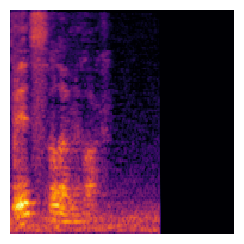

In [19]:
def npy_to_png(df, set_name):
    print(f"Starting conversion for {set_name} set...")
    for i, row in df.iterrows():
        # Check if image already exists
        if os.path.exists(row["img_path"]):
            continue

        mel_spec = np.load(row["path"])

        fig, ax = plt.subplots(figsize=(2.24, 2.24))
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        ax.axis("off")

        librosa.display.specshow(
            mel_spec, sr=22050, hop_length=HOP_LENGTH, cmap="inferno", ax=ax
        )

        buf = BytesIO()
        fig.savefig(buf, format="png", dpi=100)
        buf.seek(0)

        img = np.array(Image.open(buf))[:, :, :3]

        plt.close(fig)
        buf.close()

        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        cv2.imwrite(row["img_path"], img)
        if (i + 1) % 100 == 0:  # Print progress every 100 files
            print(f"\rConverting {set_name}: {i + 1}/{len(df)}", end="", flush=True)

    print(f"\nConversion for {set_name} complete.")


npy_to_png(train_df, "train")
npy_to_png(val_df, "val")

## PyTorch Implementation

In [ ]:
# Create a mapping from emotion labels to integers
emotion_list = sorted(train_df["emotion"].unique())
emotion_to_int = {emotion: i for i, emotion in enumerate(emotion_list)}

train_df["label"] = train_df["emotion"].map(emotion_to_int)
val_df["label"] = val_df["emotion"].map(emotion_to_int)


# Custom Dataset
class EmotionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["img_path"]
        image = Image.open(img_path).convert("RGB")
        label = self.df.iloc[idx]["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

## Data Transforms and Loaders

In [ ]:
data_transforms = {
    "train": transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
}

# Create Datasets and DataLoaders
train_dataset = EmotionDataset(train_df, transform=data_transforms["train"])
val_dataset = EmotionDataset(val_df, transform=data_transforms["val"])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_dataset), "val": len(val_dataset)}

## Model Setup

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet50(pretrained=True)

# Freeze all the parameters in the pre-trained model
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
num_ftrs = model.fc.in_features
num_classes = len(emotion_list)
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  # Only train the new layer

### Training Loop

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        # Each epoch has a training and validation phase
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = torch.tensor(0, device=device) # Initialize as a tensor on the correct device

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    return model


# Train the model
print("Starting training...")
model_ft = train_model(model, criterion, optimizer, num_epochs=10)
print("Training complete.")

## Evaluate on Validation Set

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, dataloader):
    model.eval()  # Set model to evaluate mode
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return all_labels, all_preds

# Evaluate on the validation set
print("Evaluating on validation set...")
true_labels, predicted_labels = evaluate_model(model_ft, val_loader)

# Classification Report
print("Classification Report (Validation):")
print(classification_report(true_labels, predicted_labels, target_names=emotion_list))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_list, yticklabels=emotion_list)
plt.title("Confusion Matrix (Validation)")
plt.ylabel("Actual Labels")
plt.xlabel("Predicted Labels")
plt.show()

## Evaluate on Test Set

In [ ]:
# Prepare test data
test_df = pd.read_csv(os.path.join(csv_dir, "test_features.csv"))
test_df["img_path"] = test_df["path"].apply(get_img_path)
test_df['label'] = test_df['emotion'].map(emotion_to_int)

# Convert npy to png for test set
npy_to_png(test_df, "test")

test_dataset = EmotionDataset(test_df, transform=data_transforms["val"])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# Evaluate on the test set
print("\nEvaluating on test set...")
true_labels, predicted_labels = evaluate_model(model_ft, test_loader)

# Classification Report
print("Classification Report (Test):")
print(classification_report(true_labels, predicted_labels, target_names=emotion_list))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_list, yticklabels=emotion_list)
plt.title("Confusion Matrix (Test)")
plt.ylabel("Actual Labels")
plt.xlabel("Predicted Labels")
plt.show()